# 02. 작물 수확량 예측 (Stage 1: ML)

Random Forest, XGBoost, LightGBM, CatBoost를 작물별로 비교·튜닝한다 (`src/model.py`). 평가는 연도 기준 분할(2018년 이전 학습 / 2019년 이후 테스트)로 수행해 실제 예보 상황을 흉내낸다.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root.parent if _root.name == 'notebooks' else _root
sys.path.insert(0, str(_root))
import pandas as pd
from src.data_loader import load_or_build_processed
from src.model import train_all_crops
from src import visualize as viz

panel, constraints = load_or_build_processed()
results_by_crop, comparison = train_all_crops(panel)
comparison.sort_values(['crop', 'rmse'])

,crop,model,rmse,mae,r2,cv_rmse,is_best
3,corn,catboost,23.992549,21.596880,0.426215,13.518702,True
1,corn,xgboost,24.390746,21.549111,0.407011,13.798209,False
0,corn,random_forest,24.513614,22.107794,0.401021,14.442623,False
2,corn,lightgbm,25.721740,23.427217,0.340527,14.347551,False
7,soybean,catboost,6.735866,5.714501,0.236493,4.081990,True
5,soybean,xgboost,6.736108,5.649028,0.236438,4.166375,False
4,soybean,random_forest,6.847999,5.808609,0.210861,4.324647,False
6,soybean,lightgbm,7.023686,6.108496,0.169850,4.271013,False
8,wheat,random_forest,5.703162,4.634705,0.678003,4.676925,True
11,wheat,catboost,5.729447,4.617454,0.675028,4.524465,False


## 모델별 성능 비교 (RMSE)

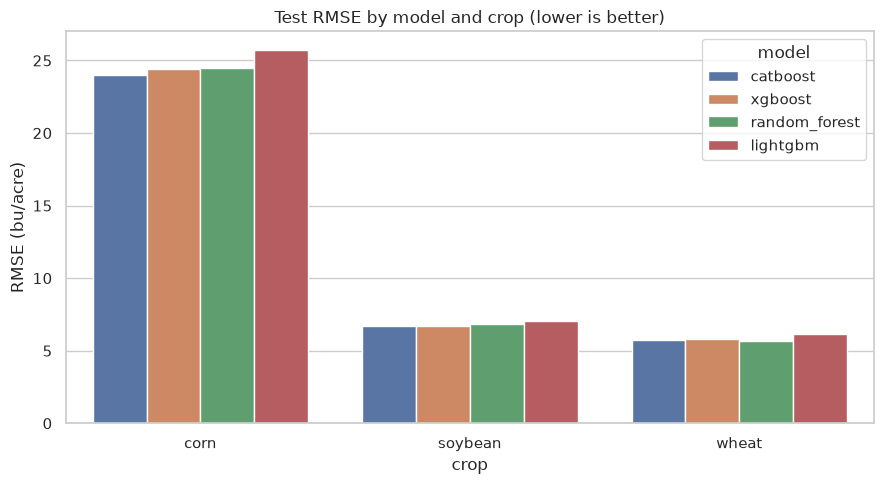

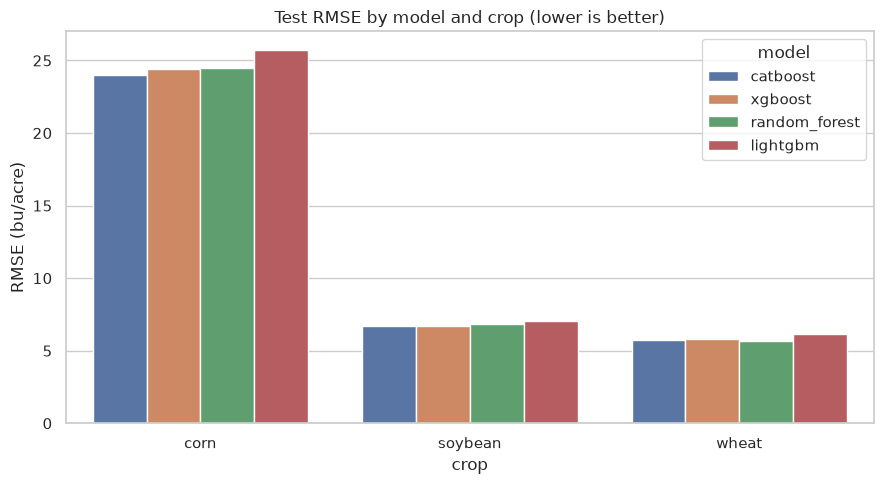

In [2]:
fig = viz.plot_model_comparison(comparison)
fig

## 최적 모델 — 실제값 vs 예측값

In [3]:
for crop, info in results_by_crop.items():
    best_name = info['best']
    print(f"{crop}: best model = {best_name}")

corn: best model = catboost
soybean: best model = catboost
wheat: best model = random_forest


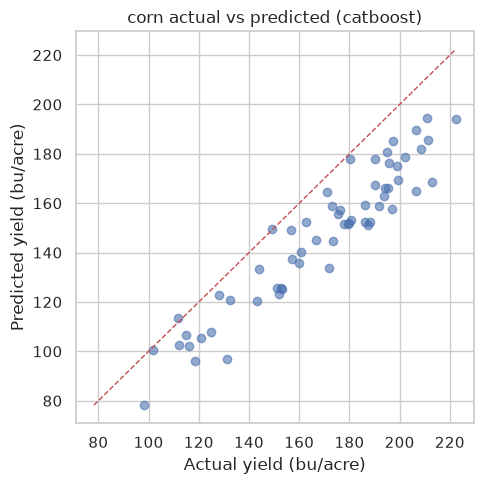

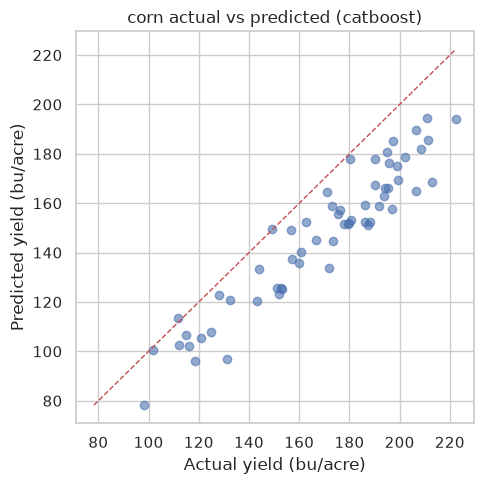

In [4]:
from src.data_loader import feature_columns
from src.model import _time_split

crop = 'corn'
best_name = results_by_crop[crop]['best']
best_model = results_by_crop[crop]['results'][best_name].estimator
cols = feature_columns()
data = panel[panel['crop'] == crop].dropna(subset=cols + ['yield_bu_acre'])
_, test = _time_split(data)
y_pred = best_model.predict(test[cols])
fig = viz.plot_actual_vs_predicted(test['yield_bu_acre'].values, y_pred, crop, best_name)
fig

## 피처 중요도

saved feature importance plots for all crops


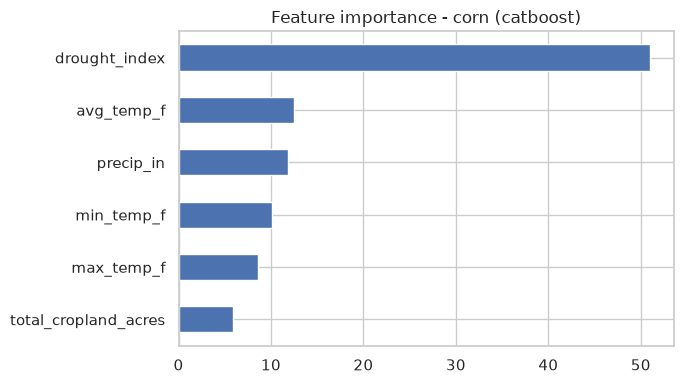

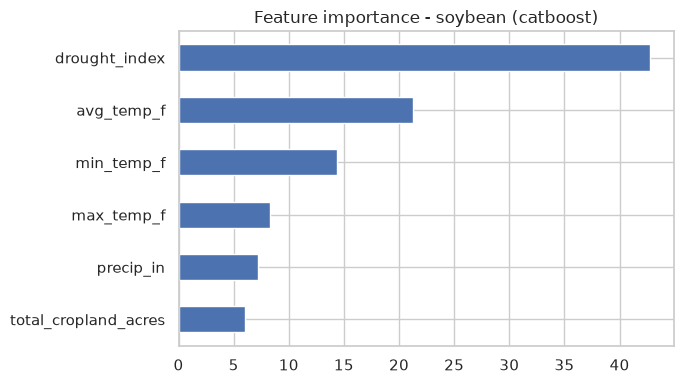

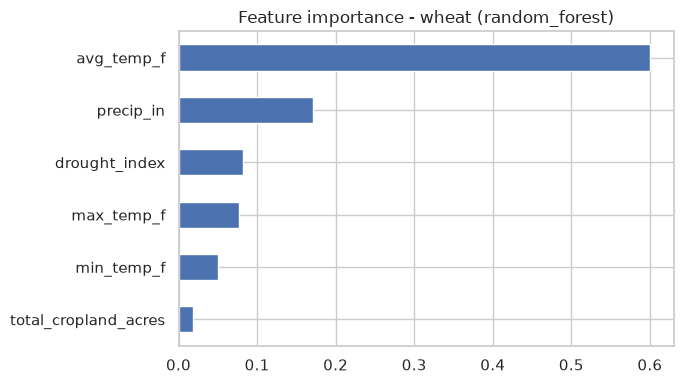

In [5]:
for crop, info in results_by_crop.items():
    best_name = info['best']
    fi = info['results'][best_name].feature_importance
    viz.plot_feature_importance(fi, crop, best_name)
print('saved feature importance plots for all crops')

## 학습된 모델 저장

`train_all_crops`가 이미 각 작물의 최적 모델을 `outputs/models/*.joblib`로 저장했다. 다음 노트북(03_optimization)에서 이 모델들을 불러와 기후 시나리오별 수확량을 예측하는 데 사용한다.

In [6]:
import pathlib
sorted(pathlib.Path('../outputs/models').glob('*.joblib')) if pathlib.Path('../outputs/models').exists() else sorted(pathlib.Path('outputs/models').glob('*.joblib'))

[PosixPath('outputs/models/corn_best_model.joblib'),
 PosixPath('outputs/models/soybean_best_model.joblib'),
 PosixPath('outputs/models/wheat_best_model.joblib')]